# Práctica 1. Representación y medida de un qubit

**Asignatura:** Computación Cuántica  
**Tema 1:** Conceptos fundamentales. Superposición cuántica  
**Duración estimada:** 45-55 minutos  
**Modalidad:** Individual o por parejas

En esta práctica representaremos estados de un qubit mediante vectores complejos, comprobaremos su normalización, aplicaremos la regla de Born y simularemos medidas en la base computacional. No utilizaremos Qiskit: trabajaremos directamente con el formalismo matemático mediante NumPy.

## Objetivos

Al finalizar la práctica serás capaz de:

- Representar estados de un qubit como vectores complejos.
- Validar y normalizar vectores de estado.
- Calcular probabilidades mediante la regla de Born.
- Simular una o varias medidas en la base computacional.
- Comparar probabilidades teóricas y frecuencias experimentales.
- Analizar el efecto del número de *shots*.
- Identificar estados diferentes que producen el mismo histograma en una base concreta.

> Completa todas las celdas marcadas con `TODO` y responde en Markdown a las preguntas planteadas.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def applyStyle():
    plt.style.use("default")

    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman", "DejaVu Serif", "serif"]
    plt.rcParams["font.size"] = 12
    plt.rcParams["axes.labelsize"] = 12
    plt.rcParams["axes.titlesize"] = 12
    plt.rcParams["xtick.labelsize"] = 10
    plt.rcParams["ytick.labelsize"] = 10
    plt.rcParams["legend.fontsize"] = 10

    plt.rcParams["xtick.direction"] = "in"
    plt.rcParams["ytick.direction"] = "in"
    plt.rcParams["xtick.top"] = True
    plt.rcParams["ytick.right"] = True
    plt.rcParams["xtick.minor.visible"] = True
    plt.rcParams["ytick.minor.visible"] = True

    plt.rcParams["lines.linewidth"] = 1.0
    plt.rcParams["lines.markersize"] = 3

    plt.rcParams["legend.frameon"] = True
    plt.rcParams["legend.edgecolor"] = "black"
    plt.rcParams["legend.fancybox"] = False

COLOR_TARGET = "#5d54a4"  # Blue violet
COLOR_PRED = "#9154a4"    # Purple
COLOR_ERR = "#404040"     # Dark gray

SEED = 42
rng = np.random.default_rng(SEED)
np.set_printoptions(precision=5, suppress=True)

applyStyle()

## Parte A. Representación de estados

### Ejercicio 1. Base computacional

Representa los estados

$$|0\rangle=\begin{pmatrix}1\\0\end{pmatrix},\qquad |1\rangle=\begin{pmatrix}0\\1\end{pmatrix}.$$

Muestra los vectores, su forma, el tipo de sus componentes y su norma.

In [2]:
ket0 = np.array([1, 0], dtype=complex)
ket1 = np.array([0, 1], dtype=complex)

for name, ket in [("|0>", ket0), ("|1>", ket1)]:
    print(name)
    print(f"  vector = {ket}")
    print(f"  shape  = {ket.shape}")
    print(f"  dtype  = {ket.dtype}")
    print(f"  norm   = {np.linalg.norm(ket):.5f}")
    print()

|0>
  vector = [1.+0.j 0.+0.j]
  shape  = (2,)
  dtype  = complex128
  norm   = 1.00000

|1>
  vector = [0.+0.j 1.+0.j]
  shape  = (2,)
  dtype  = complex128
  norm   = 1.00000



**Responde:**

1. ¿Por qué los arrays deben admitir números complejos?
2. ¿Qué dimensión tiene el espacio de estados de un qubit?
3. ¿Qué valor debe tener la norma de un estado válido?

**Respuesta:**

1. Porque las amplitudes de un estado cuántico son en general números complejos, y ahí va la fase. Si el array fuera de reales no podríamos representar estados como `psi3` (ejercicio 2), que tiene amplitud i/√2. Por eso usamos `dtype=complex` y sale `complex128`, aunque |0⟩ y |1⟩ solo tengan 1 y 0.

2. Dimensión 2. Un qubit se describe con dos amplitudes, α para |0⟩ y β para |1⟩, así que su espacio de estados es ℂ². Se ve en la salida, los dos vectores tienen `shape = (2,)`.

3. Norma 1. La norma es √(|α|² + |β|²), y |α|² + |β|² son las probabilidades de todos los resultados posibles, así que tienen que sumar 1. |0⟩ y |1⟩ cumplen esto, los dos salen con `norm = 1.00000`.

### Ejercicio 2. Superposiciones

Representa los siguientes estados y, para cada uno, muestra el vector, sus amplitudes, su norma y si está normalizado:

$$|\psi_1\rangle=\frac{|0\rangle+|1\rangle}{\sqrt{2}}$$

$$|\psi_2\rangle=\frac{\sqrt{3}}{2}|0\rangle+\frac{1}{2}|1\rangle$$

$$|\psi_3\rangle=\frac{1}{\sqrt{2}}|0\rangle+\frac{i}{\sqrt{2}}|1\rangle$$

$$|\psi_4\rangle=\frac{1+i}{2}|0\rangle+\frac{1-i}{2}|1\rangle.$$

In [3]:
states = {
    "psi1": np.array([1, 1], dtype=complex) / np.sqrt(2),
    "psi2": np.array([np.sqrt(3) / 2, 1 / 2], dtype=complex),
    "psi3": np.array([1 / np.sqrt(2), 1j / np.sqrt(2)], dtype=complex),
    "psi4": np.array([(1 + 1j) / 2, (1 - 1j) / 2], dtype=complex),
}

for name, psi in states.items():
    norm = np.linalg.norm(psi)
    print(f"{name}:")
    print(f"  vector      = {psi}")
    print(f"  alpha (|0>) = {psi[0]}")
    print(f"  beta  (|1>) = {psi[1]}")
    print(f"  norm        = {norm:.5f}")
    print(f"  normalized  = {np.isclose(norm, 1.0)}")
    print()

psi1:
  vector      = [0.70711+0.j 0.70711+0.j]
  alpha (|0>) = (0.7071067811865475+0j)
  beta  (|1>) = (0.7071067811865475+0j)
  norm        = 1.00000
  normalized  = True

psi2:
  vector      = [0.86603+0.j 0.5    +0.j]
  alpha (|0>) = (0.8660254037844386+0j)
  beta  (|1>) = (0.5+0j)
  norm        = 1.00000
  normalized  = True

psi3:
  vector      = [0.70711+0.j      0.     +0.70711j]
  alpha (|0>) = (0.7071067811865475+0j)
  beta  (|1>) = 0.7071067811865475j
  norm        = 1.00000
  normalized  = True

psi4:
  vector      = [0.5+0.5j 0.5-0.5j]
  alpha (|0>) = (0.5+0.5j)
  beta  (|1>) = (0.5-0.5j)
  norm        = 1.00000
  normalized  = True



**Responde:**

1. ¿Por qué no conviene comprobar números en coma flotante con `valor == 1.0`?
2. ¿Puede un estado válido contener amplitudes imaginarias?
3. ¿Implica una amplitud imaginaria que la probabilidad sea imaginaria?

**Respuesta:**

1. Porque el ordenador no guarda 1/√2 de forma exacta, sino con un pequeño error. Entoonces al hacer calculos, la norma puede salir 0.9999999999 en vez de 1, y `== 1.0` daría False aunque el estado sea correcto. De hecho pasa en el ejercicio 13, donde sale `norm = 0.9999999999999999`. Por eso usamos `np.isclose` que admite un margen.

2. Sí. Mientras el estado esté normalizado, da igual que las amplitudes sean complejas: `psi3` y `psi4` son ejemplos válidos y salen con `normalized = True`.

3. No. La probabilidad es el módulo al cuadrado de la amplitud, y eso siempre da un número real y no negativo. Por ejemplo, |i/√2|² = 1/2, que es la P(1) de `psi3`.

## Parte B. Validación y normalización

### Ejercicio 3. Validación de estados

Completa una función que verifique que la entrada tiene dos amplitudes, contiene valores finitos y posee norma uno. El vector nulo y los vectores con otra dimensión no son estados válidos de un qubit.

In [4]:
def isValidState(state, tolerance=1e-10):
    state = np.asarray(state, dtype=complex)

    if state.shape != (2,):  # does it have exactly two amplitudes?
        return False

    if not np.all(np.isfinite(state)):  # are all amplitudes finite?
        return False

    norm = np.linalg.norm(state)  # is the norm equal to 1?

    return bool(np.isclose(norm, 1.0, atol=tolerance))


cases = {
    "ket0": ([1, 0], "norm 1, two finite amplitudes"),
    "ket1": ([0, 1], "norm 1, two finite amplitudes"),
    "balanced": ([1 / np.sqrt(2), 1 / np.sqrt(2)], "norm 1 (|1/sqrt2|^2 * 2 = 1)"),
    "notNormalized": ([1, 1], "norm sqrt(2) != 1"),
    "zeroVector": ([0, 0], "norm 0 != 1"),
    "wrongDimension": ([1, 0, 0], "has 3 components, not 2"),
    "withNan": ([np.nan, 0], "contains NaN (not finite)"),
}

for name, (vector, justification) in cases.items():
    valid = isValidState(vector)
    print(f"{name:22s} -> {str(valid):5s} | {justification}")

ket0                   -> True  | norm 1, two finite amplitudes
ket1                   -> True  | norm 1, two finite amplitudes
balanced               -> True  | norm 1 (|1/sqrt2|^2 * 2 = 1)
notNormalized          -> False | norm sqrt(2) != 1
zeroVector             -> False | norm 0 != 1
wrongDimension         -> False | has 3 components, not 2
withNan                -> False | contains NaN (not finite)


### Ejercicio 4. Normalización

Completa la función. Debe convertir la entrada a un array complejo, comprobar su dimensión y finitud, rechazar el vector nulo y devolver un vector de norma uno.

In [5]:
def normalizeState(state):
    state = np.asarray(state, dtype=complex)

    if state.shape != (2,):
        raise ValueError("The state must have exactly two amplitudes")

    if not np.all(np.isfinite(state)):
        raise ValueError("The state contains non-finite values")

    norm = np.linalg.norm(state)
    if norm == 0.0:     # only the zero vector has norm exactly 0
        raise ValueError("The zero vector cannot be normalized")

    return state / norm

vectors = [
    np.array([1, 1], dtype=complex),
    np.array([3, 4], dtype=complex),
    np.array([1 + 1j, 2 - 1j], dtype=complex),
]

for v in vectors:
    vn = normalizeState(v)
    print(f"before: {v}   norm = {np.linalg.norm(v):.5f}")
    print(f"after:  {vn}   norm = {np.linalg.norm(vn):.5f}")
    print()

before: [1.+0.j 1.+0.j]   norm = 1.41421
after:  [0.70711+0.j 0.70711+0.j]   norm = 1.00000

before: [3.+0.j 4.+0.j]   norm = 5.00000
after:  [0.6+0.j 0.8+0.j]   norm = 1.00000

before: [1.+1.j 2.-1.j]   norm = 2.64575
after:  [0.37796+0.37796j 0.75593-0.37796j]   norm = 1.00000



**Responde:**

1. ¿Cambia la dirección del vector al normalizarlo?
2. ¿Qué ocurre con la relación entre sus componentes?
3. ¿Por qué no puede normalizarse el vector nulo?

**Respuesta:**

1. No. Normalizar solo cambia la longitud del vector, no hacia dónde apunta.

2. Se mantiene igual. La proporción entre las dos componentes no cambia, así que sigue representando el mismo estado, solo que con norma 1. Por ejemplo [3, 4] pasa a [0.6, 0.8] y la proporción sigue siendo 3/4.

3. Porque su norma es 0 y habría que dividir entre cero. Además el vector nulo no apunta a ninguna dirección, así que no representa ningún estado.

## Parte C. Regla de Born

### Ejercicio 5. Probabilidades de medida

Para $|\psi\rangle=\alpha|0\rangle+\beta|1\rangle$, la regla de Born establece $P(0)=|\alpha|^2$ y $P(1)=|\beta|^2$. Completa la función sin utilizar `estado ** 2`.

In [6]:
def computeProbabilities(state):
    state = np.asarray(state, dtype=complex)
    if not isValidState(state):
        raise ValueError("The state is not valid or is not normalized")

    probs = np.abs(state) ** 2
    return {0: float(probs[0]), 1: float(probs[1])}


testStates = {"ket0": ket0, "ket1": ket1, **states}
for name, psi in testStates.items():
    p = computeProbabilities(psi)
    total = p[0] + p[1]
    print(
        f"{name}: P(0) = {p[0]:.4f}, P(1) = {p[1]:.4f}, "
        f"sum = {total:.4f}, sum~1: {np.isclose(total, 1.0)}"
    )

ket0: P(0) = 1.0000, P(1) = 0.0000, sum = 1.0000, sum~1: True
ket1: P(0) = 0.0000, P(1) = 1.0000, sum = 1.0000, sum~1: True
psi1: P(0) = 0.5000, P(1) = 0.5000, sum = 1.0000, sum~1: True
psi2: P(0) = 0.7500, P(1) = 0.2500, sum = 1.0000, sum~1: True
psi3: P(0) = 0.5000, P(1) = 0.5000, sum = 1.0000, sum~1: True
psi4: P(0) = 0.5000, P(1) = 0.5000, sum = 1.0000, sum~1: True


### Ejercicio 6. Cálculo manual con amplitudes complejas

Considera

$$|\psi\rangle=\frac{1+i}{2}|0\rangle+\frac{1-i}{2}|1\rangle.$$

Calcula manualmente $\alpha$, $\beta$, $|\alpha|^2$, $|\beta|^2$, $P(0)$ y $P(1)$. Después compruébalo con la función anterior.

**Desarrollo y respuesta:**

Las amplitudes son α = (1+i)/2 y β = (1−i)/2.

Para el módulo al cuadrado uso que |a+bi|² = a² + b²:

- |α|² = |1+i|² / 2² = (1² + 1²) / 4 = 2/4 = 1/2
- |β|² = |1−i|² / 2² = (1² + (−1)²) / 4 = 2/4 = 1/2

Por la regla de Born:

- P(0) = |α|² = 1/2
- P(1) = |β|² = 1/2

Suman 1 --> está normalizado y la medida da 0 o 1 con la misma probabilidad.

In [7]:
print(f"alpha = {(1 + 1j) / 2},  |alpha|^2 = {np.abs((1 + 1j) / 2)**2:.4f}")
print(f"beta  = {(1 - 1j) / 2},  |beta|^2  = {np.abs((1 - 1j) / 2)**2:.4f}")

p = computeProbabilities(states["psi4"])
print(f"P(0) = {p[0]:.4f}, P(1) = {p[1]:.4f}, sum = {p[0] + p[1]:.4f}")

alpha = (0.5+0.5j),  |alpha|^2 = 0.5000
beta  = (0.5-0.5j),  |beta|^2  = 0.5000
P(0) = 0.5000, P(1) = 0.5000, sum = 1.0000


## Parte D. Simulación de la medida

### Ejercicio 7. Una medida

Completa la función para simular una medida en la base computacional. Debe devolver el entero 0 o 1 de acuerdo con las probabilidades del estado.

In [8]:
def measure(state, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    p = computeProbabilities(state)
    return int(rng.choice([0, 1], p=[p[0], p[1]]))


for name, psi in [ ("ket0", ket0), ("ket1", ket1), ("psi1", states["psi1"]), ("psi2", states["psi2"])]:
    result = measure(psi, rng)
    print(f"measure({name}) = {result}")

measure(ket0) = 0
measure(ket1) = 1
measure(psi1) = 1
measure(psi2) = 0


**Responde:**

1. ¿Qué debe producir siempre $|0\rangle$? ¿Y $|1\rangle$?
2. ¿Permite una medida aislada conocer $\alpha$ y $\beta$?
3. Si obtenemos 0, ¿podemos afirmar que el estado inicial era $|0\rangle$?

**Respuesta:**

1. En |0⟩ las amplitudes son α = 1 y β = 0, así que P(0) = |1|² = 1 y P(1) = 0. En |1⟩ es al revés y sale siempre 1. Por eso en la salida `measure(ket0) = 0` y `measure(ket1) = 1`, y con cualquier semilla saldría lo mismo.

2. No. Una medida devuelve solo un 0 o un 1. Con un único resultado no se pueden reconstruir dos amplitudes complejas, y además la fase se pierde. Para las probabilidades hay que repetir muchas veces, que es lo que hace `measureRepeatedly`.

3. No. Un 0 solo nos dice que α no es 0, no que el estado fuera |0⟩. Cualquier estado con amplitud en |0⟩ puede dar 0: `psi1` y `psi4` lo dan con probabilidad 0.5 y `psi2` con 0.75. De hecho en la celda sale `measure(psi2) = 0` y `psi2` no es |0⟩. Aasí que un solo 0 es compatible con muchos estados y no permite saber cuál era.

### Ejercicio 8. Medidas repetidas

Cada *shot* representa una nueva preparación del mismo estado seguida de una medida. La función debe rechazar valores de `shots` que no sean enteros positivos.

In [9]:
def measureRepeatedly(state, shots=1000, seed=None):
    if isinstance(shots, bool) or not isinstance(shots, (int, np.integer)):  # bool is a subclass of int
        raise TypeError("shots must be an integer")

    if shots <= 0:
        raise ValueError("shots must be positive")

    p = computeProbabilities(state)
    outcomes = np.random.default_rng(seed).choice([0, 1], size=shots, p=[p[0], p[1]])
    counts = np.bincount(outcomes, minlength=2)
    return {0: int(counts[0]), 1: int(counts[1])}

p0 = computeProbabilities(states["psi2"])[0]
shotsList = [10, 100, 1_000, 10_000, 100_000]
results = []

print(f"P(0) theoretical = {p0:.4f}\n")
print(f"{'shots':>7} | {'N(0)':>6} {'N(1)':>6} | {'f(0)':>7} {'f(1)':>7} | {'E0':>7} {'E1':>7}")

for s in shotsList:
    counts = measureRepeatedly(states["psi2"], shots=s, seed=42)
    f0 = counts[0] / s
    f1 = counts[1] / s
    e0 = abs(f0 - p0)
    e1 = abs(f1 - (1 - p0))
    results.append({"shots": s, "N0": counts[0], "N1": counts[1], "f0": f0, "f1": f1, "E0": e0, "E1": e1})
    print(f"{s:>7} | {counts[0]:>6} {counts[1]:>6} | {f0:>7.4f} {f1:>7.4f} | {e0:>7.4f} {e1:>7.4f}")

P(0) theoretical = 0.7500

  shots |   N(0)   N(1) |    f(0)    f(1) |      E0      E1
     10 |      5      5 |  0.5000  0.5000 |  0.2500  0.2500
    100 |     77     23 |  0.7700  0.2300 |  0.0200  0.0200
   1000 |    743    257 |  0.7430  0.2570 |  0.0070  0.0070
  10000 |   7558   2442 |  0.7558  0.2442 |  0.0058  0.0058
 100000 |  75035  24965 |  0.7503  0.2497 |  0.0004  0.0004


**Responde:** ¿Coinciden exactamente frecuencias y probabilidades? ¿Qué ocurre al aumentar los shots? ¿Debe disminuir el error de forma estrictamente monótona? ¿Se mide repetidamente el mismo qubit después de su colapso?

**Respuesta:**

No, las frecuencias no coinciden exactamente con las probabilidades. Con 1.000 shots sale f(0) = 0.743 en vez de 0.75, y con 10 shots incluso 0.5.

Al subir los shots, las frecuencias se acercan a 0.75 y 0.25 y el error tiende a bajar. En mi tabla baja en todos los pasos (0.25, 0.02, 0.007, 0.0058, 0.0004), pero eso no está garantizado, el error es aleatorio y en otra ejecución un paso podría tener más error que el anterior. Además aquí uso `seed=42` en todas las filas, así que cada fila es la continuación de la misma secuencia de resultados (los 10 primeros de la fila de 100 son los mismos que los de la fila de 10) y por eso la bajada sale tan ordenada.

No. Cada shot es una preparación nueva del estado seguida de una medida. Si midiéramos el mismo qubit ya colapsado, saldría siempre lo mismo.

## Parte E. Visualización

### Ejercicio 9. Convergencia de la frecuencia

Representa la frecuencia experimental de obtener 0 frente al número de shots. Añade una línea horizontal para la probabilidad teórica $P(0)=0{,}75$ y usa escala logarítmica en el eje horizontal. Incluye título, etiquetas, leyenda y cuadrícula.

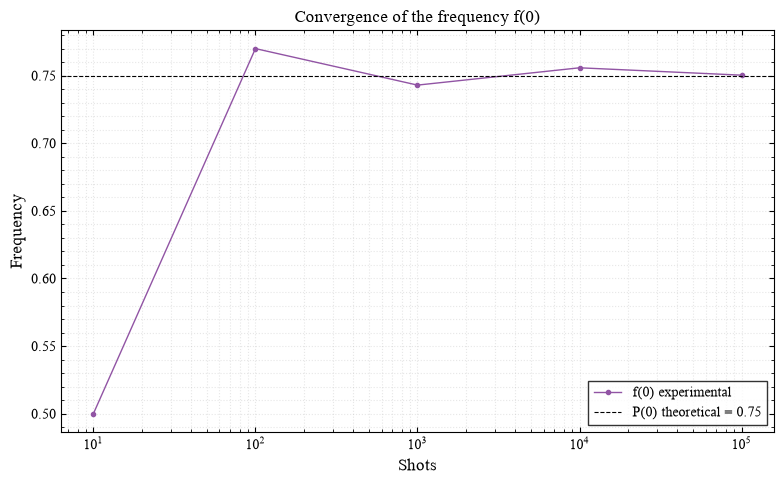

In [10]:
shotsList = [r["shots"] for r in results]
f0List = [r["f0"] for r in results]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(shotsList, f0List, "o-", color=COLOR_PRED, label="f(0) experimental")
ax.axhline(0.75, color="black", linestyle="--", linewidth=0.8, label="P(0) theoretical = 0.75")
ax.set_xscale("log")
ax.set_xlabel("Shots")
ax.set_ylabel("Frequency")
ax.set_title("Convergence of the frequency f(0)")
ax.legend(loc="best")
ax.grid(True, which="both", linestyle=":", alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretación de la gráfica:**

Con 10 shots la frecuencia se queda en 0.5, muy lejos del valor teórico. Al pasar a 100 shots ya se sitúa cerca de 0.75. A partir de ahí se mueve en oscilaciones pequeñas alrededor de la línea teórica hasta quedar en aprox 0.75 en 100.000 shots.

### Ejercicio 10. Histograma de resultados

Para 1.000 shots, representa un diagrama de barras con los conteos de 0 y 1. Añade el valor numérico sobre cada barra.

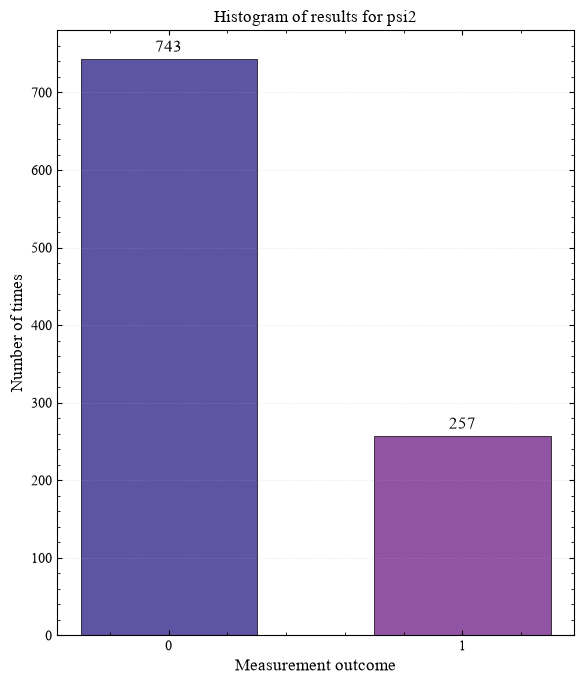

In [11]:
counts = measureRepeatedly(states["psi2"], shots=1000, seed=42)

possibleResults = [0, 1]
values = [counts[0], counts[1]]

fig, ax = plt.subplots(figsize=(6, 7))
bars = ax.bar(possibleResults, values, color=[COLOR_TARGET, COLOR_PRED], width=0.6, edgecolor="black", linewidth=0.5)
ax.set_xticks(possibleResults)
ax.set_xticklabels(["0", "1"])
ax.set_xlabel("Measurement outcome")
ax.set_ylabel("Number of times")
ax.set_title("Histogram of results for psi2")
for bar, value in zip(bars, values): ax.text(bar.get_x() + bar.get_width() / 2, value + 5, str(value), ha="center", va="bottom")
ax.grid(True, axis="y", linestyle=":", alpha=0.3)
plt.tight_layout()
plt.show()

**Responde:** ¿Qué información muestra el histograma? ¿Muestra directamente las amplitudes? ¿Permite determinar la fase relativa?

**Respuesta:**

El histograma muestra cuántas veces salió cada resultado en las 1.000 medidas: 743 veces 0 y 257 veces 1. Eso son conteos, y divididos entre 1.000 dan las frecuencias 0.743 y 0.257, que estiman las probabilidades (muy cerca del 0.75 y 0.25 teóricos).

No muestra las amplitudes, solo podemos estimar |α|² y |β|², no α y β en sí.

Y no permite ver la fase relativa, es decir otro estado con las mismas probabilidades pero distinta fase daría exactamente este mismo histograma. Para distinguirlos habría que medir en otra base.

## Parte F. Estados con las mismas probabilidades

### Ejercicio 11. El papel de la fase

Compara los estados

$$|\psi_A\rangle=\frac{|0\rangle+|1\rangle}{\sqrt{2}},\qquad |\psi_B\rangle=\frac{|0\rangle-|1\rangle}{\sqrt{2}},\qquad |\psi_C\rangle=\frac{|0\rangle+i|1\rangle}{\sqrt{2}}.$$

Represéntalos, valida su normalización, calcula sus probabilidades y simula 10.000 medidas de cada uno.

In [12]:
psiA = np.array([1, 1], dtype=complex) / np.sqrt(2)
psiB = np.array([1, -1], dtype=complex) / np.sqrt(2)
psiC = np.array([1, 1j], dtype=complex) / np.sqrt(2)

phaseStates = {"psiA": psiA, "psiB": psiB, "psiC": psiC}

for i, (name, psi) in enumerate(phaseStates.items()):
    valid = isValidState(psi)
    p = computeProbabilities(psi)
    counts = measureRepeatedly(psi, shots=10_000, seed=SEED + i)  # different seed for each state
    print(f"{name}: {psi}")
    print(f"  valid = {valid} | P(0) = {p[0]:.3f}, P(1) = {p[1]:.3f}")
    print(f"  measurements -> {counts}")
    print()

print("psiA equals psiB?", np.allclose(psiA, psiB))
print("psiA equals psiC?", np.allclose(psiA, psiC))
probsA = computeProbabilities(psiA)
sameProbs = all(np.isclose(computeProbabilities(psi)[k], probsA[k]) for psi in phaseStates.values() for k in (0, 1))

print("Same probabilities?", sameProbs)

psiA: [0.70711+0.j 0.70711+0.j]
  valid = True | P(0) = 0.500, P(1) = 0.500
  measurements -> {0: 5015, 1: 4985}

psiB: [ 0.70711+0.j -0.70711+0.j]
  valid = True | P(0) = 0.500, P(1) = 0.500
  measurements -> {0: 4953, 1: 5047}

psiC: [0.70711+0.j      0.     +0.70711j]
  valid = True | P(0) = 0.500, P(1) = 0.500
  measurements -> {0: 5028, 1: 4972}

psiA equals psiB? False
psiA equals psiC? False
Same probabilities? True


**Responde:**

1. ¿Son iguales los tres vectores?
2. ¿Producen las mismas probabilidades en la base computacional?
3. ¿Podemos concluir que representan el mismo estado?
4. ¿Permite esta medida detectar sus diferencias?
5. ¿Qué información no aparece en los histogramas?
6. ¿Qué fenómeno permitirá aprovechar posteriormente estas diferencias?

**Respuesta:**

1. No, los tres vectores son distintos, cambian en el signo o la fase de la segunda amplitud (+1, −1, +i).

2. Sí, los tres dan P(0) = P(1) = 0.5 en la base computacional, porque |1/√2|², |−1/√2|² y |i/√2|² valen todos 1/2.

3. No, que las probabilidades coincidan en una base no significa que sean el mismo estado. Se diferencian en una fase relativa, no global, así que son estados físicamente distintos (ejercicio 12).

4. No, esta medida no detecta las diferencias. Los conteos salen 5015/4985, 4953/5047 y 5028/4972, y lo que cambia entre ellos es solo ruido estadístico, del orden de 0.5/√10.000 = 0.005. Uso una semilla distinta para cada estado, porque con la misma semilla saldrían exactamente los mismos conteos al tener las mismas probabilidades.

5. No aparece la fase relativa (el signo o la fase de la componente de |1⟩).

6. La interferencia. Aplicando una operación antes de medir esa fase se convierte en diferencias de probabilidad que sí se ven.

### Ejercicio 12. Fase global y fase relativa

Compara

$$|\phi_A\rangle=\frac{1}{\sqrt{2}}\begin{pmatrix}1\\1\end{pmatrix},\quad |\phi_B\rangle=-\frac{1}{\sqrt{2}}\begin{pmatrix}1\\1\end{pmatrix},\quad |\phi_C\rangle=\frac{1}{\sqrt{2}}\begin{pmatrix}1\\-1\end{pmatrix}.$$

¿Qué estados se diferencian solo por una fase global? ¿Dónde hay una diferencia de fase relativa? ¿Cuáles son físicamente equivalentes?

**Respuesta:**

A y B se diferencian solo en una fase global, B es A entero multiplicado por −1 = e^(iπ). Ese factor multiplica a las dos componentes por igual, así que la relación entre ellas no cambia. Son el mismo estado físico y dan los mismos resultados en cualquier medida.

C es distinto, el signo menos afecta solo a la segunda componente, no a las dos. Eso cambia la relación entre las amplitudes, así que es una fase relativa, y sí representa un estado físicamente diferente. De hecho C es el mismo estado que `psiB` del ejercicio 11.

Físicamente equivalentes son A y B. C es un estado distinto.

## Parte G. Construcción segura de estados

### Ejercicio 13. Función de construcción

Completa una función que acepte amplitudes reales o complejas, rechace valores no finitos y el vector nulo, y devuelva el estado normalizado.

In [13]:
def createState(alpha, beta):
    state = np.array([alpha, beta], dtype=complex)
    return normalizeState(state)  # normalizeState already rejects non-finite values and the zero vector

psi = createState(1 + 2j, 3 - 1j)
print("normalized state =", psi)
print("norm =", np.linalg.norm(psi))
print("valid?", isValidState(psi))
print("probs =", computeProbabilities(psi))
print()

invalidCases = {
    "withInf": ((np.inf, 1), "infinite amplitude"),
    "withNan": ((np.nan, 0), "NaN amplitude"),
    "zeroVector": ((0, 0), "norm 0, cannot be normalized"),
}

for name, ((alpha, beta), justification) in invalidCases.items():
    try:
        createState(alpha, beta)
        outcome = "NOT DETECTED"
    except ValueError:
        outcome = "ValueError"
    print(f"{name:12s} -> {outcome:12s} | {justification}")

normalized state = [0.2582+0.5164j 0.7746-0.2582j]
norm = 0.9999999999999999
valid? True
probs = {0: 0.3333333333333333, 1: 0.6666666666666666}

withInf      -> ValueError   | infinite amplitude
withNan      -> ValueError   | NaN amplitude
zeroVector   -> ValueError   | norm 0, cannot be normalized


**Responde:** ¿Es siempre conveniente normalizar automáticamente una entrada? ¿En qué contexto sería preferible lanzar una excepción? ¿Puede la normalización ocultar un error matemático?

**Respuesta:**

No siempre conviene normalizar automáticamente, si esperabas que la entrada ya estuviera normalizada y no lo estaba, la función lo arregla/hace sin avisar y no te enteras de que algo iba mal antes.

Es preferible lanzar una excepción cuando la entrada debería venir ya normalizada, por ejemplo el resultado de un cálculo anterior o un estado que te pasa otra función. Si no tiene norma 1 es que hubo un error antes, y es mejor que falle ahí que seguir con un estado corregido a escondidas. Es lo que hace `computeProbabilities`, que lanza `ValueError` en vez de normalizar.

Sí, la normalización puede ocultar un error matemático. Por ejemplo, si te equivocaste en un coeficiente, al normalizar el vector con errores igualmente sale con norma 1 y parece correcto.

## Reto avanzado. Incertidumbre estadística

Para una variable binaria con probabilidad $p$, la desviación típica de la frecuencia estimada con $N$ shots es

$$\sigma_f=\sqrt{\frac{p(1-p)}{N}}.$$

Con $p=0{,}75$, calcula $\sigma_f$ para todos los números de shots anteriores y añade a la gráfica las curvas $p-\sigma_f$ y $p+\sigma_f$.

In [14]:
def plotConvergence(shots, f0, p=0.75, bands=None, title="Convergence of f(0)"):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(shots, f0, "o-", color=COLOR_PRED, label="f(0) experimental")
    ax.axhline(p, color="black", linestyle="--", linewidth=0.8, label=f"P(0) = {p}")

    if bands is not None:
        ax.plot(shots, p + bands, color=COLOR_TARGET, linestyle=":", label=r"$p \pm \sigma_f$")
        ax.plot(shots, p - bands, color=COLOR_TARGET, linestyle=":")
        ax.fill_between(shots, p - bands, p + bands, color=COLOR_TARGET, alpha=0.15)

    ax.set_xscale("log")
    ax.set_xlabel("Shots")
    ax.set_ylabel("Frequency")
    ax.set_title(title)
    ax.legend(loc="best")
    ax.grid(True, which="both", linestyle=":", alpha=0.3)
    plt.tight_layout()
    plt.show()

In [15]:
p = 0.75
N = np.array(shotsList, dtype=float)
sigmaF = np.sqrt(p * (1 - p) / N)

print(f"{'shots':>7} | {'sigma_f':>10}")
print("-" * 22)
for n, s in zip(shotsList, sigmaF):
    print(f"{n:>7} | {s:>10.5f}")

  shots |    sigma_f
----------------------
     10 |    0.13693
    100 |    0.04330
   1000 |    0.01369
  10000 |    0.00433
 100000 |    0.00137


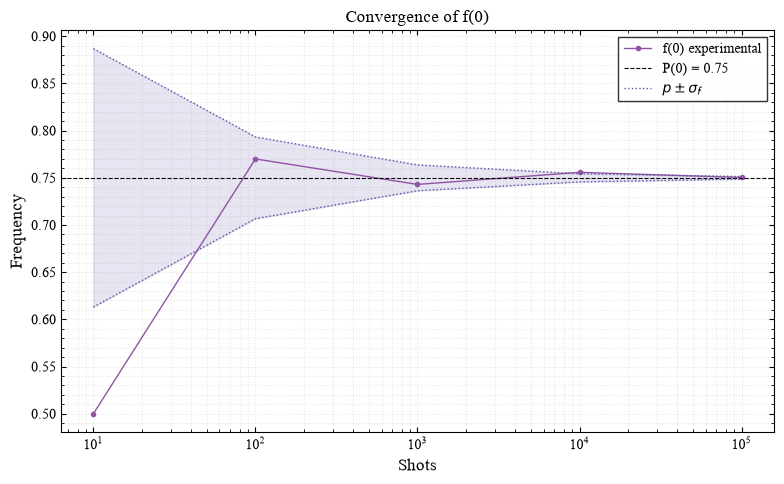

In [16]:
plotConvergence(shotsList, f0List, p=p, bands=sigmaF, title="Convergence of f(0)")

**Responde:** ¿Cómo varía la incertidumbre con $N$? ¿Cuántos shots hacen falta aproximadamente para reducirla a la mitad? ¿Por qué aumentar shots presenta rendimiento decreciente?

**Respuesta:**

La incertidumbre baja como 1/√N. Cada vez que multiplicamos los shots por 10, σ_f se divide entre √10 ≈ 3.16 (de 0.13693 a 0.04330, y así en cada fila).

Para reducirla a la mitad hay que multiplicar los shots por 4. Como σ_f depende de 1/√N, para dividir σ entre 2 hace falta N × 2² = N × 4. Al aparecer la raíz cuadrada, los primeros shots reducen mucho la incertidumbre, pero cada shot extra aporta cada vez menos. Pasar de 10 a 100 shots baja σ_f en 0.094, y pasar de 10.000 a 100.000, que son 90.000 shots más, solo la baja en 0.003.

En la gráfica dos de los cinco puntos quedan fuera de la banda, el de 10 shots está a unas 1.8σ y el de 10.000 a 1.3σ. Es normal, porque ±σ solo recoge alrededor del 68 % de los casos, así que se espera que 1 o 2 de cada 5 puntos queden fuera.

## Pruebas mínimas

Ejecuta estas pruebas después de completar las funciones y añade las necesarias para comprobar entradas no válidas.

In [17]:
def raises(errorType, func, *args, **kwargs):
    try:
        func(*args, **kwargs)
        return False

    except errorType:
        return True

assert isValidState([1, 0])
assert isValidState([0, 1])
assert not isValidState([1, 1])
assert not isValidState([0, 0])
assert not isValidState([1, 0, 0])
assert np.isclose(np.linalg.norm(normalizeState([1, 1])), 1.0)
assert np.isclose(sum(computeProbabilities(states["psi2"]).values()), 1.0)
assert measure(states["psi1"], np.random.default_rng(42)) in (0, 1)
assert sum(measureRepeatedly(states["psi2"], 1000, 42).values()) == 1000
assert raises(ValueError, normalizeState, [0, 0])                 
assert raises(ValueError, normalizeState, [1, 0, 0])              
assert raises(ValueError, normalizeState, [np.nan, 1])            
assert raises(ValueError, computeProbabilities, [1, 1])           
assert raises(ValueError, measureRepeatedly, states["psi2"], 0)   
assert raises(ValueError, measureRepeatedly, states["psi2"], -5) 
assert raises(TypeError, measureRepeatedly, states["psi2"], 3.5)  
assert raises(TypeError, measureRepeatedly, states["psi2"], True)
assert raises(ValueError, createState, np.inf, 1)                 
assert raises(ValueError, createState, 0, 0)                      
assert not isValidState([np.nan, 0])                              
assert computeProbabilities(ket0) == {0: 1.0, 1: 0.0}
assert computeProbabilities(ket1) == {0: 0.0, 1: 1.0}
assert all(measure(ket0, np.random.default_rng(s)) == 0 for s in range(20))  
assert all(measure(ket1, np.random.default_rng(s)) == 1 for s in range(20))  

## Conclusiones

Redacta un máximo de 200 palabras respondiendo:

1. ¿Qué diferencia existe entre amplitud y probabilidad?
2. ¿Qué relación existe entre shots, frecuencias y probabilidades?
3. ¿Por qué una sola medida no permite reconstruir el estado?
4. ¿Por qué dos estados diferentes pueden producir el mismo histograma?
5. ¿Qué diferencia conceptual existe entre una superposición y una mezcla clásica?

**Conclusión:**

1. La amplitud es un número complejo (módulo y fase) y la probabilidad es su módulo al cuadrado, que siempre sale real y no negativo. La amplitud lleva más información que la probabilidad, porque incluye la fase.

2. Cada shot es una preparación del estado seguida de una medida. La frecuencia estima la probabilidad teórica, y cuantos más shots hagamos, más se acerca a ella, con una incertidumbre que baja como 1/√N.

3. Porque una medida solo devuelve un 0 o un 1 y colapsa el estado. No da los valores de α y β. Además, un mismo resultado puede venir de muchos estados distintos. Para reconstruir el estado hay que preparar y medir muchas copias.

4. Porque la medida en la base computacional solo ve |α|² y |β|². Dos estados con las mismas probabilidades pero distinta fase relativa, por ejemplo |0⟩+|1⟩ y |0⟩−|1⟩ dan el mismo histograma aunque sean diferentes.

5. En la mezcla clásica el sistema ya está en 0 o en 1 y solo hay desconocimiento. En la superposición es un único estado con fase relativa, capaz de producir interferencia. (coinciden en probabilidades en una base, pero no son lo mismo)

## Lista de comprobación antes de entregar

- [x] Todas las celdas se ejecutan en orden sin errores.
- [x] No quedan bloques `TODO` sin completar.
- [x] Las probabilidades suman uno.
- [x] Las gráficas tienen títulos, etiquetas y leyendas.
- [x] Las respuestas justifican los resultados.
- [x] Las pruebas mínimas se ejecutan correctamente.
- [x] El notebook conserva las salidas antes de la entrega.